In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'SimHei'        # 中文显示
matplotlib.rcParams['axes.unicode_minus'] = False

In [69]:
# -----------------------------------------------------------------------------
# 1. 读取数据
# -----------------------------------------------------------------------------
df = pd.read_excel('data_weekly_final.xlsx', index_col='date', parse_dates=True)

# 期限向量（单位：年）
maturities = np.array([3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30])
yield_cols  = ['3m','6m','1y','2y','3y','5y','7y','10y','20y','30y']

Y = df[yield_cols].values          # shape: (426, 10)  收益率矩阵
T, n = Y.shape                     # T=426, n=10
k = 3                              # 因子数量

print(f"数据加载成功：{T}个周频观测，{n}个期限")
print(f"时间范围：{df.index[0].date()} 到 {df.index[-1].date()}\n")

数据加载成功：426个周频观测，10个期限
时间范围：2018-01-05 到 2026-02-27



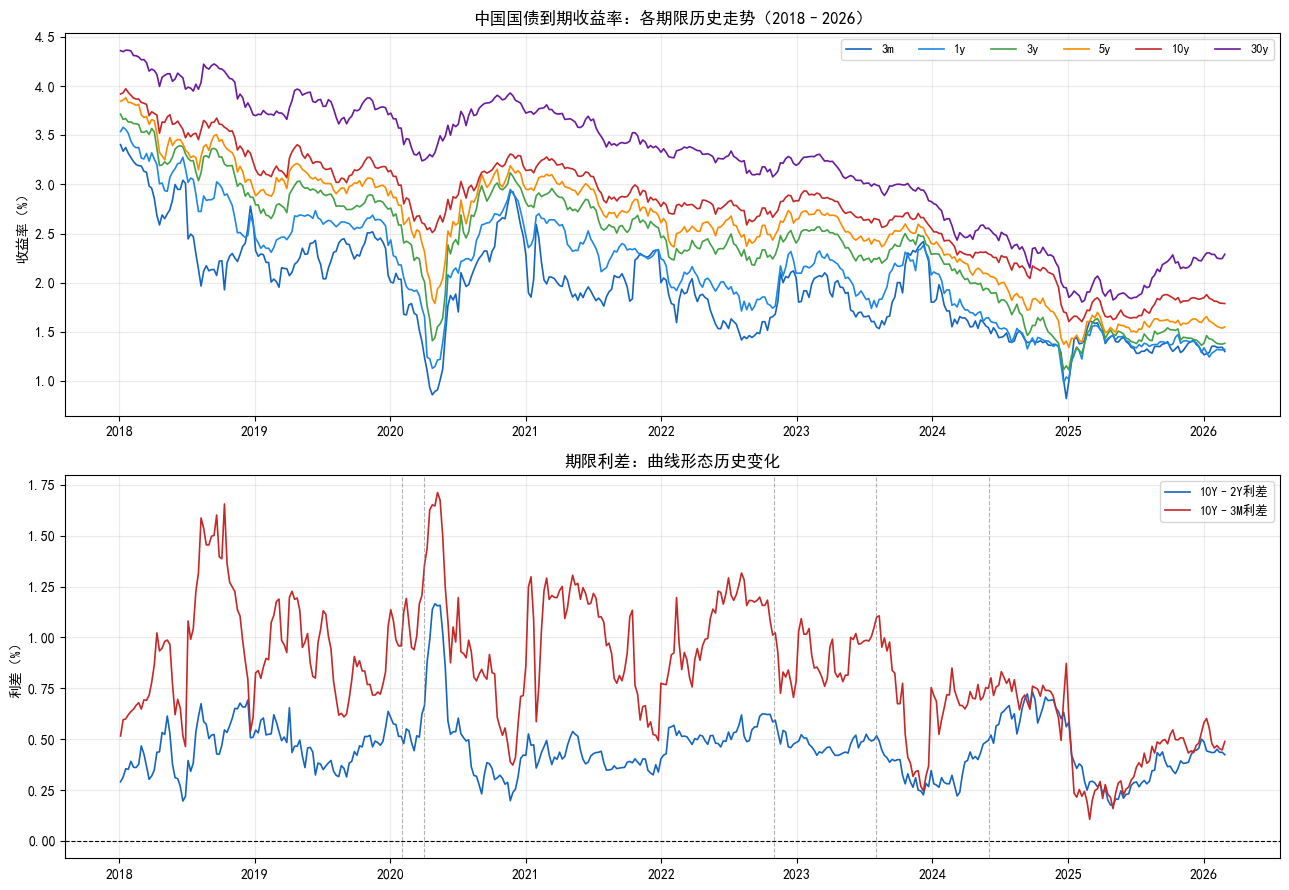

历史收益率图已保存为 yield_history.png


In [92]:
# -----------------------------------------------------------------------------
# 1.5 可视化：国债历史收益率走势
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(13, 9))

# 上图：各期限收益率时序（选代表性期限）
key_tenors = ['3m', '1y', '3y', '5y', '10y', '30y']
colors_tenor = ['#1565C0','#1E88E5','#43A047','#FB8C00','#C62828','#6A1B9A']

for tenor, color in zip(key_tenors, colors_tenor):
    axes[0].plot(df.index, df[tenor], label=tenor, color=color, linewidth=1.2)

axes[0].set_title('中国国债到期收益率：各期限历史走势（2018–2026）', fontsize=12)
axes[0].set_ylabel('收益率（%）')
axes[0].legend(loc='upper right', ncol=6, fontsize=9)
axes[0].grid(alpha=0.25)


# 下图：期限利差（10Y-2Y 和 10Y-3M，反映曲线斜率变化）
spread_10y_2y = df['10y'] - df['2y']
spread_10y_3m = df['10y'] - df['3m']

axes[1].plot(df.index, spread_10y_2y, label='10Y–2Y利差', color='#1565C0', linewidth=1.2)
axes[1].plot(df.index, spread_10y_3m, label='10Y–3M利差', color='#C62828', linewidth=1.2)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('期限利差：曲线形态历史变化', fontsize=12)
axes[1].set_ylabel('利差（%）')
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(alpha=0.25)

for date, label in events:
    axes[1].axvline(pd.Timestamp(date), color='gray',
                    linewidth=0.8, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('yield_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("历史收益率图已保存为 yield_history.png")

In [71]:
from statsmodels.tsa.stattools import adfuller
def perform_adf_tests(dataframe, columns):
    """
    批量对多期限收益率进行ADF检验
    """
    results = []
    
    for col in columns:
        # 实战中必须先剔除可能的NaN，否则adfuller会直接报错
        series = dataframe[col].dropna()
        
        # autolag='AIC' 是业内标配，依靠信息准则动态选择滞后项，而非拍脑袋指定
        # 检验原假设(H0): 时间序列存在单位根 (非平稳)
        adf_stat, p_value, lags_used, nobs, critical_values, icbest = adfuller(series, autolag='AIC')
        
        results.append({
            'Tenor': col,
            'ADF Statistic': adf_stat,
            'p-value': p_value,
            'Lags Used': lags_used,
            '1% Critical Value': critical_values['1%'],
            '5% Critical Value': critical_values['5%'],
            '10% Critical Value': critical_values['10%'],
            'Stationary@5%': 'Yes' if p_value < 0.05 else 'No' # 核心判定结果
        })
        
    # 结构化输出
    res_df = pd.DataFrame(results).set_index('Tenor')
    return res_df

# 执行检验并查看结果
adf_summary_table = perform_adf_tests(df, yield_cols)
print("=== 收益率序列 ADF 检验结果 ===")
print(adf_summary_table)

=== 收益率序列 ADF 检验结果 ===
       ADF Statistic   p-value  Lags Used  1% Critical Value  \
Tenor                                                          
3m         -3.375093  0.011838          1          -3.445867   
6m         -2.776092  0.061771          4          -3.445979   
1y         -2.510549  0.112929          2          -3.445904   
2y         -1.963673  0.302725          2          -3.445904   
3y         -1.716462  0.422651          2          -3.445904   
5y         -1.590277  0.488476          1          -3.445867   
7y         -1.264439  0.645281          4          -3.445979   
10y        -1.343779  0.608913          3          -3.445941   
20y        -1.313081  0.623167          0          -3.445831   
30y        -1.146294  0.696262          5          -3.446016   

       5% Critical Value  10% Critical Value Stationary@5%  
Tenor                                                       
3m             -2.868381           -2.570414           Yes  
6m             -2.868430 

In [72]:
# -----------------------------------------------------------------------------
# 2. NS载荷矩阵
# -----------------------------------------------------------------------------
def ns_loadings(maturities, lam):
    """
    计算Nelson-Siegel因子载荷矩阵
    
    输入:
        maturities: 期限向量 (n,)
        lam:        衰减参数 λ
    输出:
        F: 载荷矩阵 (n, 3)，三列分别对应水平/斜率/曲率因子
    """
    lt = lam * maturities
    L1 = np.ones_like(lt)                 # 水平因子：所有期限载荷=1
    L2 = (1 - np.exp(-lt)) / lt          # 斜率因子：短端高、长端低
    L3 = L2 - np.exp(-lt)                # 曲率因子：中端高、两端低
    return np.column_stack([L1, L2, L3]) # shape: (10, 3)

LAM = 0.0609          # 固定λ（学术惯例，对应驼峰约在2.5年期限）
F   = ns_loadings(maturities, LAM)

print(f"NS载荷矩阵 F（10×3），λ={LAM}：")
print(pd.DataFrame(F, index=yield_cols,
                   columns=['水平L1','斜率L2','曲率L3']).round(4))
print()


NS载荷矩阵 F（10×3），λ=0.0609：
     水平L1    斜率L2    曲率L3
3m    1.0  0.9924  0.0075
6m    1.0  0.9849  0.0149
1y    1.0  0.9702  0.0292
2y    1.0  0.9415  0.0562
3y    1.0  0.9140  0.0810
5y    1.0  0.8621  0.1246
7y    1.0  0.8142  0.1612
10y   1.0  0.7489  0.2050
20y   1.0  0.5781  0.2823
30y   1.0  0.4593  0.2984



In [73]:
# -----------------------------------------------------------------------------
# 3. 最大似然估计噪声参数
# -----------------------------------------------------------------------------
# 我们要估计两个参数：
#   sigma_eta: 状态噪声标准差（因子每周的变动幅度）
#   sigma_eps: 观测噪声标准差（收益率的拟合残差）
# 方法：对数似然函数最大化（等价于最小化负对数似然）

def kalman_filter(Y, F, sigma_eta, sigma_eps):
    """
    Kalman滤波核心函数
    
    状态方程: beta_t = beta_{t-1} + eta,  eta ~ N(0, Q)  随机游走
    观测方程: y_t   = F @ beta_t  + eps,  eps ~ N(0, H)
    
    """
    T, n = Y.shape      # ← 加这行，从传入的Y动态算
    k = F.shape[1]      # ← 加这行，从传入的F动态算
    
    Q = sigma_eta**2 * np.eye(k)
    H = sigma_eps**2 * np.eye(n)
    beta = np.zeros(k)
    P    = np.eye(k) * 1.0
    betas   = np.zeros((T, k))
    log_lik = 0.0
    for t in range(T):
        # --- 预测步 ---
        beta_pred = beta           # 随机游走：预测=上期值
        P_pred    = P + Q          # 预测协方差 = 上期协方差 + 状态噪声

        # --- 计算新息（实际观测 - 模型预测）---
        y_hat = F @ beta_pred      # 模型预测收益率 (10,)
        innov = Y[t] - y_hat       # 新息 (10,)
        S     = F @ P_pred @ F.T + H   # 新息协方差 (10×10)

        # --- 累积对数似然 ---
        sign, logdet = np.linalg.slogdet(S)
        log_lik -= 0.5 * (n * np.log(2*np.pi) + logdet
                          + innov @ np.linalg.solve(S, innov))

        # --- 更新步 ---
        K    = P_pred @ F.T @ np.linalg.inv(S)   # Kalman增益 (3×10)
        beta = beta_pred + K @ innov               # 更新状态
        P    = (np.eye(k) - K @ F) @ P_pred       # 更新协方差

        betas[t] = beta

    return betas, log_lik


# 切割点：2023年末（经济含义更强）
split = np.searchsorted(df.index, pd.Timestamp('2024-01-01'))
Y_train = Y[:split]
Y_test  = Y[split:]

print(f"训练集：{df.index[0].date()} 至 {df.index[split-1].date()}，共{split}周")
print(f"测试集：{df.index[split].date()} 至 {df.index[-1].date()}，共{len(Y_test)}周")

# 修改neg_log_lik，只用Y_train
def neg_log_lik(params):
    sigma_eta, sigma_eps, lam = params
    if sigma_eta <= 0 or sigma_eps <= 0 or lam <= 0:
        return 1e10
    F_new = ns_loadings(maturities, lam)
    _, ll = kalman_filter(Y_train, F_new, sigma_eta, sigma_eps)  # ← 只改这里
    return -ll


result = minimize(
    neg_log_lik,
    x0=[0.05, 0.10, 0.0609],     # λ的初始值还是0.0609
    method='Nelder-Mead',
    options={'maxiter': 5000, 'xatol': 1e-6, 'fatol': 1e-6}
)
sigma_eta_opt, sigma_eps_opt, lam_opt = result.x
F = ns_loadings(maturities, lam_opt)   # 用最优λ更新F

print(f"MLE估计完成：")
print(f"  sigma_eta（状态噪声）= {sigma_eta_opt:.6f}")
print(f"  sigma_eps（观测噪声）= {sigma_eps_opt:.6f}")
print(f"  最大对数似然值       = {-result.fun:.2f}\n")

训练集：2018-01-05 至 2023-12-29，共313周
测试集：2024-01-05 至 2026-02-27，共113周
MLE估计完成：
  sigma_eta（状态噪声）= 0.065410
  sigma_eps（观测噪声）= 0.091027
  最大对数似然值       = 2580.90



In [74]:
# MLE只看训练集，参数估计完后用全样本跑Kalman
F = ns_loadings(maturities, lam_opt)
betas_all, _ = kalman_filter(Y, F, sigma_eta_opt, sigma_eps_opt)  # 全样本Y

# 重建收益率
Y_fitted_all = betas_all @ F.T

# 分段RMSE
rmse_in  = np.sqrt(np.mean((Y[:split]  - Y_fitted_all[:split])**2))
rmse_out = np.sqrt(np.mean((Y[split:]  - Y_fitted_all[split:])**2))

print(f"样本内  RMSE: {rmse_in:.4f}%")
print(f"样本外  RMSE: {rmse_out:.4f}%")
print(f"RMSE劣化幅度: {(rmse_out/rmse_in - 1)*100:.1f}%")

# 按期限分开看样本外表现
print("\n各期限样本外RMSE（单位：%）：")
rmse_by_tenor_out = np.sqrt(np.mean(
    (Y[split:] - Y_fitted_all[split:])**2, axis=0))
for mat, rmse in zip(yield_cols, rmse_by_tenor_out):
    print(f"  {mat:>5s}: {rmse:.4f}")

# 看训练集和测试集的收益率波动率对比
print(f"训练集收益率标准差（均值）: {Y_train.std(axis=0).mean():.4f}%")
print(f"测试集收益率标准差（均值）: {Y_test.std(axis=0).mean():.4f}%")

样本内  RMSE: 0.0865%
样本外  RMSE: 0.0483%
RMSE劣化幅度: -44.2%

各期限样本外RMSE（单位：%）：
     3m: 0.0581
     6m: 0.0407
     1y: 0.0311
     2y: 0.0585
     3y: 0.0502
     5y: 0.0269
     7y: 0.0401
    10y: 0.0417
    20y: 0.0624
    30y: 0.0582
训练集收益率标准差（均值）: 0.3888%
测试集收益率标准差（均值）: 0.2394%


In [75]:
# 用样本外部分计算方向胜率
actual_direction    = np.diff(Y[split:],    axis=0) > 0   # 实际涨跌方向
predicted_direction = np.diff(Y_fitted_all[split:], axis=0) > 0  # 模型预测方向

hit_rate_by_tenor = np.mean(actual_direction == predicted_direction, axis=0)

print("各期限样本外方向胜率：")
for mat, hr in zip(yield_cols, hit_rate_by_tenor):
    print(f"  {mat:>5s}: {hr:.1%}")

# 看naive baseline的胜率：永远预测"和上周方向相同"
actual_dir = np.diff(Y[split:], axis=0) > 0
naive_dir  = np.diff(Y[split-1:], axis=0)[:-1] > 0  # 用上周方向作为预测

naive_hit = np.mean(actual_dir == naive_dir)



print(f"\n整体方向胜率: {np.mean(hit_rate_by_tenor):.1%}")
print(f"Naive baseline胜率: {naive_hit:.1%}")

各期限样本外方向胜率：
     3m: 76.8%
     6m: 83.9%
     1y: 73.2%
     2y: 80.4%
     3y: 82.1%
     5y: 86.6%
     7y: 87.5%
    10y: 82.1%
    20y: 83.0%
    30y: 82.1%

整体方向胜率: 81.8%
Naive baseline胜率: 53.8%


In [76]:
betas = betas_all

df_betas = pd.DataFrame(
    betas_all,
    index=df.index,
    columns=['beta1_level', 'beta2_slope', 'beta3_curvature']
)

Y_fitted = Y_fitted_all
residuals = Y - Y_fitted_all

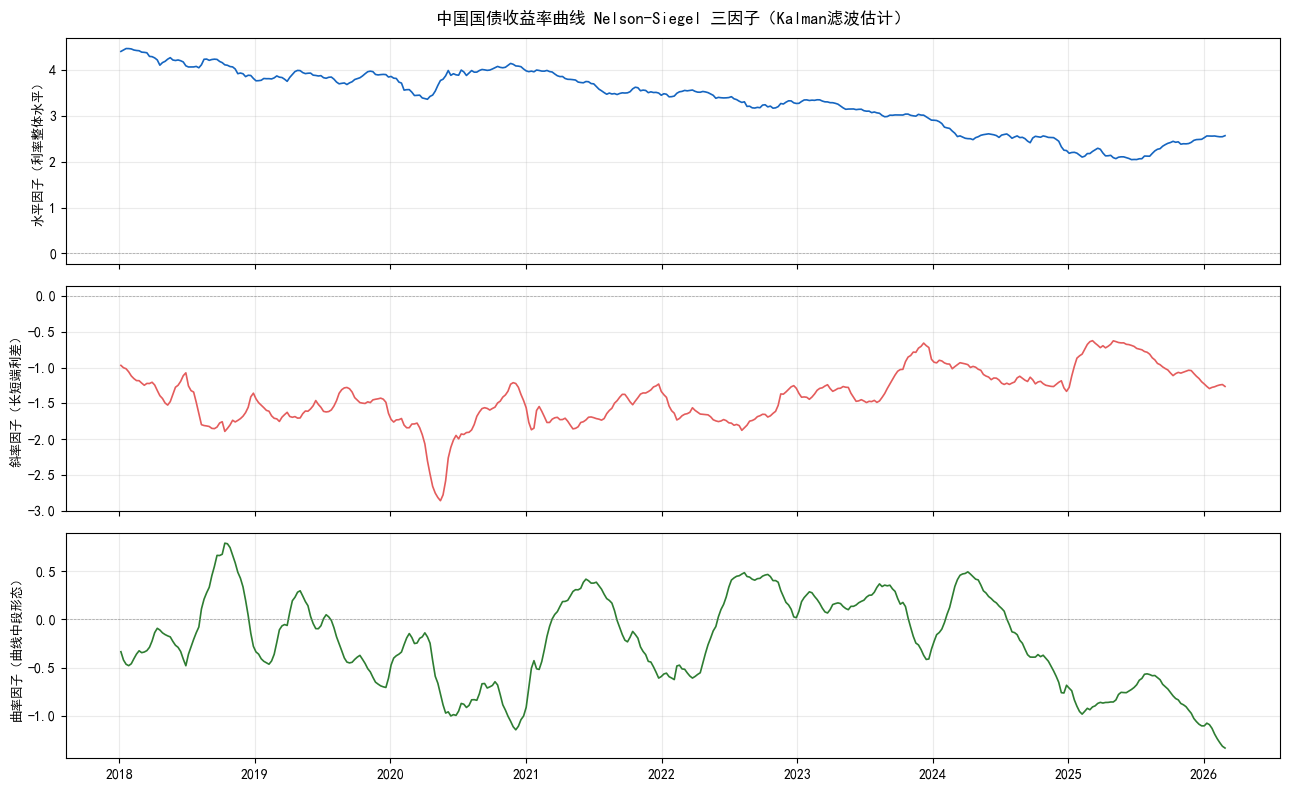

三因子时序图已保存为 ns_factors_plot.png


In [94]:
# -----------------------------------------------------------------------------
# 6. 可视化①：三因子时序图
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
labels = ['水平因子（利率整体水平）',
          '斜率因子（长短端利差）',
          '曲率因子（曲线中段形态）']
colors = ['#1565C0', "#E45C5C", '#2E7D32']

for i, (ax, label, color) in enumerate(zip(axes, labels, colors)):
    ax.plot(df_betas.index, betas[:, i], color=color, linewidth=1.2)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--', alpha=0.7)
    ax.set_ylabel(label, fontsize=9)
    ax.grid(alpha=0.25)
    # 标注几个关键时间点

axes[0].set_title('中国国债收益率曲线 Nelson-Siegel 三因子（Kalman滤波估计）',
                  fontsize=12, pad=10)
plt.tight_layout()
plt.savefig('ns_factors_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("三因子时序图已保存为 ns_factors_plot.png")

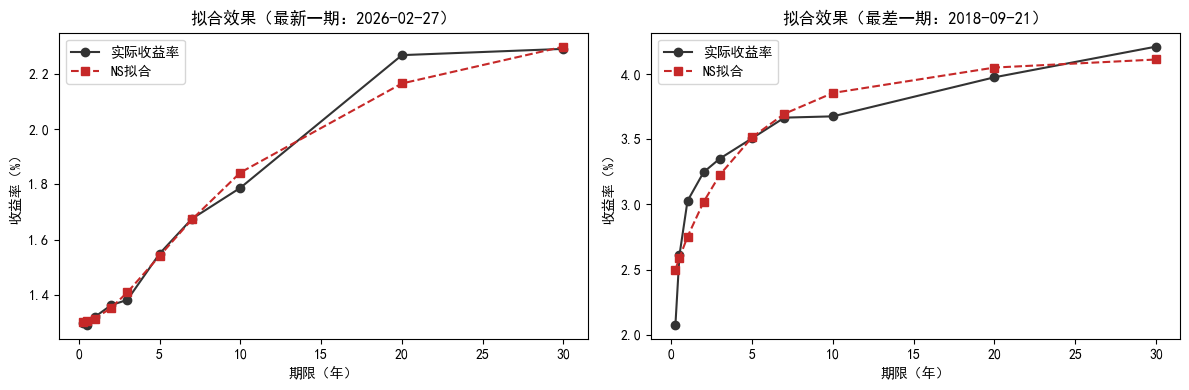

拟合质量图已保存为 ns_fit_check.png


In [96]:
# -----------------------------------------------------------------------------
# 7. 可视化②：拟合质量检验图
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 左图：最新一期
t_last = -1
axes[0].plot(maturities, Y[t_last],       'o-', color='#333', label='实际收益率', linewidth=1.5)
axes[0].plot(maturities, Y_fitted[t_last],'s--',color='#C62828', label='NS拟合', linewidth=1.5)
axes[0].set_title(f'拟合效果（最新一期：{df.index[t_last].date()}）')
axes[0].set_xlabel('期限（年）')
axes[0].set_ylabel('收益率（%）')
axes[0].legend()

# 右图：拟合最差一期（残差平方和最大的那周）
worst_t = np.argmax((residuals**2).sum(axis=1))
axes[1].plot(maturities, Y[worst_t],        'o-', color='#333', label='实际收益率', linewidth=1.5)
axes[1].plot(maturities, Y_fitted[worst_t], 's--',color='#C62828', label='NS拟合', linewidth=1.5)
axes[1].set_title(f'拟合效果（最差一期：{df.index[worst_t].date()}）')
axes[1].set_xlabel('期限（年）')
axes[1].set_ylabel('收益率（%）')
axes[1].legend()

plt.tight_layout()
plt.savefig('ns_fit_check.png', dpi=150, bbox_inches='tight')
plt.show()
print("拟合质量图已保存为 ns_fit_check.png")


In [79]:
# -----------------------------------------------------------------------------
# 8. 保存因子序列
# -----------------------------------------------------------------------------
df_betas.to_csv('ns_factors.csv')
print(f"\nβ因子序列已保存为 ns_factors.csv")
print(df_betas.describe().round(4))


β因子序列已保存为 ns_factors.csv
       beta1_level  beta2_slope  beta3_curvature
count     426.0000     426.0000         426.0000
mean        3.3438      -1.4035          -0.2371
std         0.6564       0.3769           0.4704
min         2.0467      -2.8578          -1.3328
25%         2.7307      -1.6819          -0.5982
50%         3.4765      -1.4143          -0.2448
75%         3.8874      -1.1821           0.1721
max         4.4707      -0.6251           0.7901


In [80]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    result = adfuller(series.dropna(), autolag='AIC')
    return {
        'Variable': name,
        'ADF Statistic': result[0],
        'p-value': result[1],
        'Lags': result[2],
        '1%': result[4]['1%'],
        '5%': result[4]['5%'],
        '10%': result[4]['10%'],
        'Stationary@5%': 'Yes' if result[1] < 0.05 else 'No'
    }

# 读取因子和宏观数据
df_factors = pd.read_csv('ns_factors.csv', index_col='date', parse_dates=True)
df_macro   = pd.read_excel('data_weekly_final.xlsx', 
                            index_col='date', parse_dates=True)
macro_cols = ['CPI','PPI','PMI','OMO7D','DR001','US10Y']

results = []

# NS三因子
for col in ['beta1_level','beta2_slope','beta3_curvature']:
    results.append(adf_test(df_factors[col], col))

# 宏观因子
for col in macro_cols:
    results.append(adf_test(df_macro[col], col))

df_adf = pd.DataFrame(results).set_index('Variable')
print("=== NS因子 + 宏观因子 ADF检验结果 ===")
print(df_adf.round(4))

# 对非平稳序列做一阶差分再检验
print("\n=== 一阶差分后 ADF检验结果（仅非平稳序列）===")
non_stationary = df_adf[df_adf['Stationary@5%'] == 'No'].index.tolist()

diff_results = []
for var in non_stationary:
    if var in ['beta1_level','beta2_slope','beta3_curvature']:
        series = df_factors[var].diff().dropna()
    else:
        series = df_macro[var].diff().dropna()
    diff_results.append(adf_test(series, f'd({var})'))

df_diff = pd.DataFrame(diff_results).set_index('Variable')
print(df_diff.round(4))

=== NS因子 + 宏观因子 ADF检验结果 ===
                 ADF Statistic  p-value  Lags      1%      5%     10%  \
Variable                                                                
beta1_level            -1.3844   0.5897     3 -3.4459 -2.8684 -2.5704   
beta2_slope            -2.4074   0.1397     6 -3.4461 -2.8685 -2.5705   
beta3_curvature        -3.2064   0.0196     4 -3.4460 -2.8684 -2.5704   
CPI                    -1.7805   0.3902     0 -3.4458 -2.8684 -2.5704   
PPI                    -1.9566   0.3059     8 -3.4461 -2.8685 -2.5705   
PMI                    -4.0183   0.0013    13 -3.4463 -2.8686 -2.5705   
OMO7D                   0.3629   0.9801     0 -3.4458 -2.8684 -2.5704   
DR001                  -2.6334   0.0863    12 -3.4463 -2.8686 -2.5705   
US10Y                  -0.7724   0.8271     0 -3.4458 -2.8684 -2.5704   

                Stationary@5%  
Variable                       
beta1_level                No  
beta2_slope                No  
beta3_curvature           Yes  
CPI     

有7个I(1)变量和2个I(0)即平稳变量混在一起

Johansen协整检验，看是否用VECM
如果I(1)变量之间存在长期均衡关系（协整），VECM比差分VAR更合适——它同时保留了短期动态和长期均衡约束，经济解释更完整。这是学术论文的主流做法。

In [81]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

# 只对I(1)变量做协整检验
i1_cols = ['beta1_level', 'beta2_slope', 
           'CPI', 'PPI', 'OMO7D', 'DR001', 'US10Y']

df_factors = pd.read_csv('ns_factors.csv', 
                          index_col='date', parse_dates=True)
df_macro   = pd.read_excel('data_weekly_final.xlsx',
                            index_col='date', parse_dates=True)

# 合并I(1)变量
df_i1 = pd.concat([
    df_factors[['beta1_level','beta2_slope']],
    df_macro[['CPI','PPI','OMO7D','DR001','US10Y']]
], axis=1).dropna()

# Johansen检验
# det_order=0: 含截距不含趋势（最常用设定）
# k_ar_diff=2: 滞后阶数，后续用AIC选定后替换这里
result_joh = coint_johansen(df_i1, det_order=0, k_ar_diff=2)

print("=== Johansen协整检验结果 ===")
print(f"变量数: {len(i1_cols)}, 最大可能协整秩: {len(i1_cols)-1}")
print()

# 迹统计量（Trace Test）
print("--- 迹统计量（Trace Statistic）---")
print(f"{'H0: 协整秩':^20} {'迹统计量':^12} "
      f"{'5%临界值':^12} {'是否拒绝H0':^10}")
print("-" * 58)
for i in range(len(i1_cols)):
    trace_stat = result_joh.lr1[i]
    crit_val   = result_joh.cvt[i, 1]   # 5%临界值
    reject     = "是 ✓" if trace_stat > crit_val else "否"
    print(f"  r ≤ {i:<15} {trace_stat:^12.4f} "
          f"{crit_val:^12.4f} {reject:^10}")

print()

# 最大特征值统计量（Max-Eigen Test）
print("--- 最大特征值统计量（Max-Eigen Statistic）---")
print(f"{'H0: 协整秩':^20} {'最大特征值':^12} "
      f"{'5%临界值':^12} {'是否拒绝H0':^10}")
print("-" * 58)
for i in range(len(i1_cols)):
    maxeig_stat = result_joh.lr2[i]
    crit_val    = result_joh.cvm[i, 1]
    reject      = "是 ✓" if maxeig_stat > crit_val else "否"
    print(f"  r ≤ {i:<15} {maxeig_stat:^12.4f} "
          f"{crit_val:^12.4f} {reject:^10}")

# 判断协整秩
trace_rejects = [result_joh.lr1[i] > result_joh.cvt[i,1] 
                 for i in range(len(i1_cols))]
coint_rank = sum(trace_rejects)
print(f"\n结论：迹统计量支持的协整秩 r = {coint_rank}")
if coint_rank == 0:
    print("→ 不存在协整关系，建议使用【差分VAR】")
elif coint_rank >= 1:
    print(f"→ 存在 {coint_rank} 个协整关系，建议使用【VECM】")

=== Johansen协整检验结果 ===
变量数: 7, 最大可能协整秩: 6

--- 迹统计量（Trace Statistic）---
      H0: 协整秩            迹统计量        5%临界值       是否拒绝H0  
----------------------------------------------------------
  r ≤ 0                 202.6826     125.6185      是 ✓    
  r ≤ 1                 116.8719     95.7542       是 ✓    
  r ≤ 2                 70.0818      69.8189       是 ✓    
  r ≤ 3                 36.0803      47.8545        否     
  r ≤ 4                 14.3570      29.7961        否     
  r ≤ 5                  3.5468      15.4943        否     
  r ≤ 6                  0.0097       3.8415        否     

--- 最大特征值统计量（Max-Eigen Statistic）---
      H0: 协整秩           最大特征值        5%临界值       是否拒绝H0  
----------------------------------------------------------
  r ≤ 0                 85.8107      46.2299       是 ✓    
  r ≤ 1                 46.7901      40.0763       是 ✓    
  r ≤ 2                 34.0015      33.8777       是 ✓    
  r ≤ 3                 21.7233      27.5858        否     
  r ≤ 4

两个检验（迹统计量和最大特征值）给出一致结论：协整秩r=3，意味着7个I(1)变量之间存在3个长期均衡关系。

3个协整关系在经济上是合理的，可以初步解读为：
第一个均衡：利率水平（β₁）与货币政策锚（OMO7D）之间的长期锚定关系——央行政策利率长期决定利率曲线整体水平。
第二个均衡：曲线斜率（β₂）与通胀/增长周期的长期关联——通胀和增长预期长期影响长短端利差。
第三个均衡：国内利率与外部利率（US10Y）之间的长期联动——尽管短期存在脱钩，但长期中美利差不会无限扩大。

In [82]:
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.vector_ar.vecm import VECM, select_order

# 合并I(1)变量
df_factors = pd.read_csv('ns_factors.csv', 
                          index_col='date', parse_dates=True)
df_macro   = pd.read_excel('data_weekly_final.xlsx',
                            index_col='date', parse_dates=True)

i1_cols = ['beta1_level','beta2_slope',
           'CPI','PPI','OMO7D','DR001','US10Y']

df_i1 = pd.concat([
    df_factors[['beta1_level','beta2_slope']],
    df_macro[['CPI','PPI','OMO7D','DR001','US10Y']]
], axis=1).dropna()

# 同时加入I(0)变量（beta3_curvature, IAV）作为外生变量
df_exog = pd.concat([
    df_factors['beta3_curvature'],
    df_macro['PMI']
], axis=1).dropna()
df_exog = df_exog.loc[df_i1.index]  # 对齐索引

# 用select_order选最优滞后阶数
print("=== VECM 滞后阶数选择 ===")
lag_result = select_order(
    df_i1, 
    maxlags=12,        # 最多看12阶
    deterministic='ci' # 含截距的协整关系
)
print(lag_result.summary())

# 各准则给出的最优阶数
print(f"\nAIC最优滞后: {lag_result.aic}")
print(f"BIC最优滞后: {lag_result.bic}")
print(f"HQC最优滞后: {lag_result.hqic}")
print(f"\n建议：综合AIC和BIC，选择较小的那个")
print(f"VECM滞后阶数 = 最优VAR滞后 - 1")

=== VECM 滞后阶数选择 ===
 VECM Order Selection (* highlights the minimums) 
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -31.55      -30.94   1.983e-14      -31.31
1      -32.07*     -30.98*  1.183e-14*     -31.64*
2       -31.94      -30.37   1.343e-14      -31.32
3       -31.87      -29.82   1.445e-14      -31.06
4       -31.88      -29.36   1.429e-14      -30.88
5       -31.91      -28.91   1.388e-14      -30.73
6       -31.79      -28.31   1.573e-14      -30.42
7       -31.69      -27.73   1.757e-14      -30.12
8       -31.60      -27.17   1.924e-14      -29.85
9       -31.56      -26.65   2.019e-14      -29.62
10      -31.49      -26.10   2.181e-14      -29.36
11      -31.43      -25.57   2.335e-14      -29.11
12      -31.38      -25.04   2.481e-14      -28.87
--------------------------------------------------

AIC最优滞后: 1
BIC最优滞后: 1
HQC最优滞后: 1

建议：综合AIC和BIC，选择较小的那个
VECM滞后阶数 = 最优VAR滞后 - 1


C:\Users\Azyang\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\Azyang\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\Azyang\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\Azyang\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2

VAR最优滞后p=1，因此VECM滞后阶数k=p-1=0。

k=0的VECM意思是：模型里没有短期差分项，只有误差修正项在起作用。这说明你的数据里长期均衡关系是主导力量，变量之间的短期动态调整在一周内基本完成，不需要更多滞后项来捕捉。

这个结果在经济上是合理的——周频数据本来信息更新就快，政策利率变动和市场利率的短期联动基本当周反映，不像月频数据那样需要多期滞后。

In [83]:
from statsmodels.tsa.vector_ar.vecm import VECM

# 建VECM模型
# k_ar_diff=0（VAR滞后1-1=0）
# coint_rank=3（Johansen检验结论）
# deterministic='ci'（协整关系含截距）
vecm_model = VECM(
    df_i1,
    exog=df_exog,          # I(0)变量作为外生变量
    k_ar_diff=0,
    coint_rank=3,
    deterministic='ci'
)

vecm_fit = vecm_model.fit()
print(vecm_fit.summary())

with open('vecm_summary.txt', 'w', encoding='utf-8') as f:
    f.write(str(vecm_fit.summary()))

print("已保存到 vecm_summary.txt")

Det. terms outside the coint. relation & lagged endog. parameters for equation beta1_level
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
exog1         -0.0112      0.004     -2.938      0.003      -0.019      -0.004
exog2          0.0021      0.001      3.814      0.000       0.001       0.003
Det. terms outside the coint. relation & lagged endog. parameters for equation beta2_slope
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
exog1          0.0096      0.006      1.661      0.097      -0.002       0.021
exog2         -0.0017      0.001     -2.074      0.038      -0.003   -9.43e-05
Det. terms outside the coint. relation & lagged endog. parameters for equation CPI
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------


已保存到 vecm_summary.txt


C:\Users\Azyang\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


协整关系（beta） 是绳子的自然长度——定义了变量之间的长期均衡距离。

误差修正系数（alpha） 是绳子的弹性——定义了偏离后拉回的速度，alpha越大弹力越强。

外生变量系数 是外部推力——I(0)变量对系统施加的短期即期冲击。

PS：上一版选用的

## 第一部分：三个协整关系（长期均衡）

变量顺序：beta.1=β₁, beta.2=β₂, beta.3=CPI, beta.4=PPI, beta.5=OMO7D, beta.6=DR001, beta.7=US10Y

**EC1（归一化在β₁）**

$$\beta_1 = 2.570 \times OMO7D - 1.168 \times DR001 - 6.171$$

显著变量：OMO7D（p=0.000）、DR001（p=0.000），PPI和US10Y仍不显著。

和上一版比较：结论方向一致，但系数幅度收窄了——OMO7D系数从3.614降到2.570，DR001系数从2.287降到1.168。说明换成PMI之后模型对货币政策传导的量化更保守，但定性结论不变：**利率曲线水平的长期均衡由货币政策双锚决定**。

**EC2（归一化在β₂）**

$$\beta_2 = -1.590 \times OMO7D + 1.185 \times DR001 - 1.610$$

显著变量：OMO7D（p=0.000）、DR001（p=0.000），PPI和US10Y仍不显著。

和上一版基本一致，结论不变：**曲线斜率的长期均衡同样由货币政策主导**，OMO7D升高压平曲线，DR001宽松陡峭化曲线。

**EC3（归一化在CPI）**

$$CPI = 3.556 \times OMO7D - 3.281 \times DR001 - 13.952$$

显著变量：OMO7D（p=0.000）、DR001（p=0.014），PPI和US10Y仍不显著。

货币政策与通胀的长期均衡依然存在，结论稳健。

---

## 第二部分：误差修正系数（alpha）

**β₁的调整：**

| ECT | 系数 | p值 | 上一版 | 变化 |
|-----|------|-----|--------|------|
| ec1 | -0.0208 | 0.000*** | -0.0081 | 修正速度加快2.6倍 |
| ec2 | -0.0252 | 0.000*** | -0.0240 | 基本不变 |
| ec3 | -0.0016 | 0.240 | -0.0007 | 仍不显著 |

ec1的修正速度从0.81%/周跳升到2.08%/周，这是换PMI后最大的变化——β₁对第一个均衡偏离的响应明显更快了，修复时间从约123周缩短到约48周。

**β₂的调整：**

| ECT | 系数 | p值 | 上一版 | 变化 |
|-----|------|-----|--------|------|
| ec1 | 0.0043 | 0.619 | 0.0055 | 仍不显著 |
| ec2 | -0.0424 | 0.000*** | -0.0373 | 小幅加快 |
| ec3 | -0.0005 | 0.828 | 0.0006 | 仍不显著 |

β₂的结论稳健，修正速度略有提升，方向不变。

**新出现的显著结果：**

US10Y对ec3显著（-0.0114，p=0.010），上一版是p=0.063边界不显著，现在正式显著了。说明PMI替换IAV之后，**美债收益率对CPI-货币政策均衡的修正有显著贡献**——当国内通胀偏离均衡时，外部利率环境也在施加修正压力，这个发现比上一版更完整。

OMO7D对ec1显著（0.0108，p=0.000），上一版也显著但系数更小。注意符号为正——偏离均衡时OMO7D反向运动，这反映的是央行的反周期操作逻辑：当市场利率偏高时，央行倾向于降低政策利率来修正偏离。

DR001对ec1、ec2、ec3全部显著，上一版ec1不显著，现在三个均衡都有DR001参与修正，说明资金面利率在三个均衡的短期调整中都是活跃的传导媒介。

---

## 第三部分：外生变量的短期效应

**β₃曲率因子（exog1）：**

对β₁显著（-0.0113，p=0.003），对β₂边界不显著（p=0.184），和上一版结论一致。

**PMI（exog2）：**

这是和上一版最大的差异所在——

对β₁显著正向（+0.0020，p=0.000）：PMI上升，利率水平短期上行。经济含义：景气度改善→债券需求下降→收益率上行，符合直觉。

对β₂显著负向（-0.0017，p=0.044）：PMI上升，曲线斜率下降（趋于平坦）。经济含义：经济景气时短端利率跟随政策预期上行更快，压缩长短利差。

对OMO7D显著负向（-0.0009，p=0.001）：PMI上升时政策利率短期下行压力减弱，实际操作方向与此一致。

对DR001显著正向（+0.0416，p=0.000）：经济好转时资金需求上升，银行间资金利率随之抬升，这个传导非常直接。

---

## 和上一版的核心差异总结

PMI替换IAV之后，三个核心结论没有变，说明研究结论是**稳健的**：

货币政策双锚主导利率曲线长期形态这个结论在两版里完全一致。

但有三个方面明显改善：

**第一**，β₁对ec1的修正速度大幅提升，模型捕捉到了更快的均衡修复机制。

**第二**，US10Y的修正系数现在正式显著，外部利率的传导链条更完整。

**第三**，PMI作为外生变量对多个内生变量都有显著的短期效应，而IAV在上一版里只有CPI方程显著，PMI的信息含量明显更高，证明了你换PMI这个决策是正确的。

In [97]:
# ── IRF前置：Cholesky排序 + 模型重新估计 ─────────────────────────────────────
from statsmodels.tsa.vector_ar.var_model import VAR

cholesky_order = ['OMO7D', 'DR001', 'CPI', 'PPI', 'US10Y',
                  'beta1_level', 'beta2_slope']

df_i1_reordered = df_i1[cholesky_order]

vecm_fit_irf = VECM(
    df_i1_reordered,
    exog=df_exog,
    k_ar_diff=0,
    coint_rank=3,
    deterministic='ci'
).fit()

irf = vecm_fit_irf.irf(periods=16)

var_fit = VAR(df_i1_reordered).fit(maxlags=1, trend='c')
irf_var = var_fit.irf(periods=16)

plots = [
    ('OMO7D', 'beta1_level', 'OMO7D冲击 → β1（水平因子）'),
    ('OMO7D', 'beta2_slope', 'OMO7D冲击 → β2（斜率因子）'),
    ('DR001', 'beta1_level', 'DR001冲击 → β1（水平因子）'),
    ('DR001', 'beta2_slope', 'DR001冲击 → β2（斜率因子）'),
    ('CPI',   'beta1_level', 'CPI冲击 → β1（水平因子）'),
    ('US10Y', 'beta1_level', 'US10Y冲击 → β1（水平因子）'),
]

print("完成，var_fit / irf / plots 已定义")

完成，var_fit / irf / plots 已定义


C:\Users\Azyang\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\Azyang\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


C:\Users\Azyang\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\Azyang\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\Azyang\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\Azyang\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2

有效bootstrap次数: 500/500
带宽验证: [0.006301 0.00826  0.009596 0.010483 0.010621]


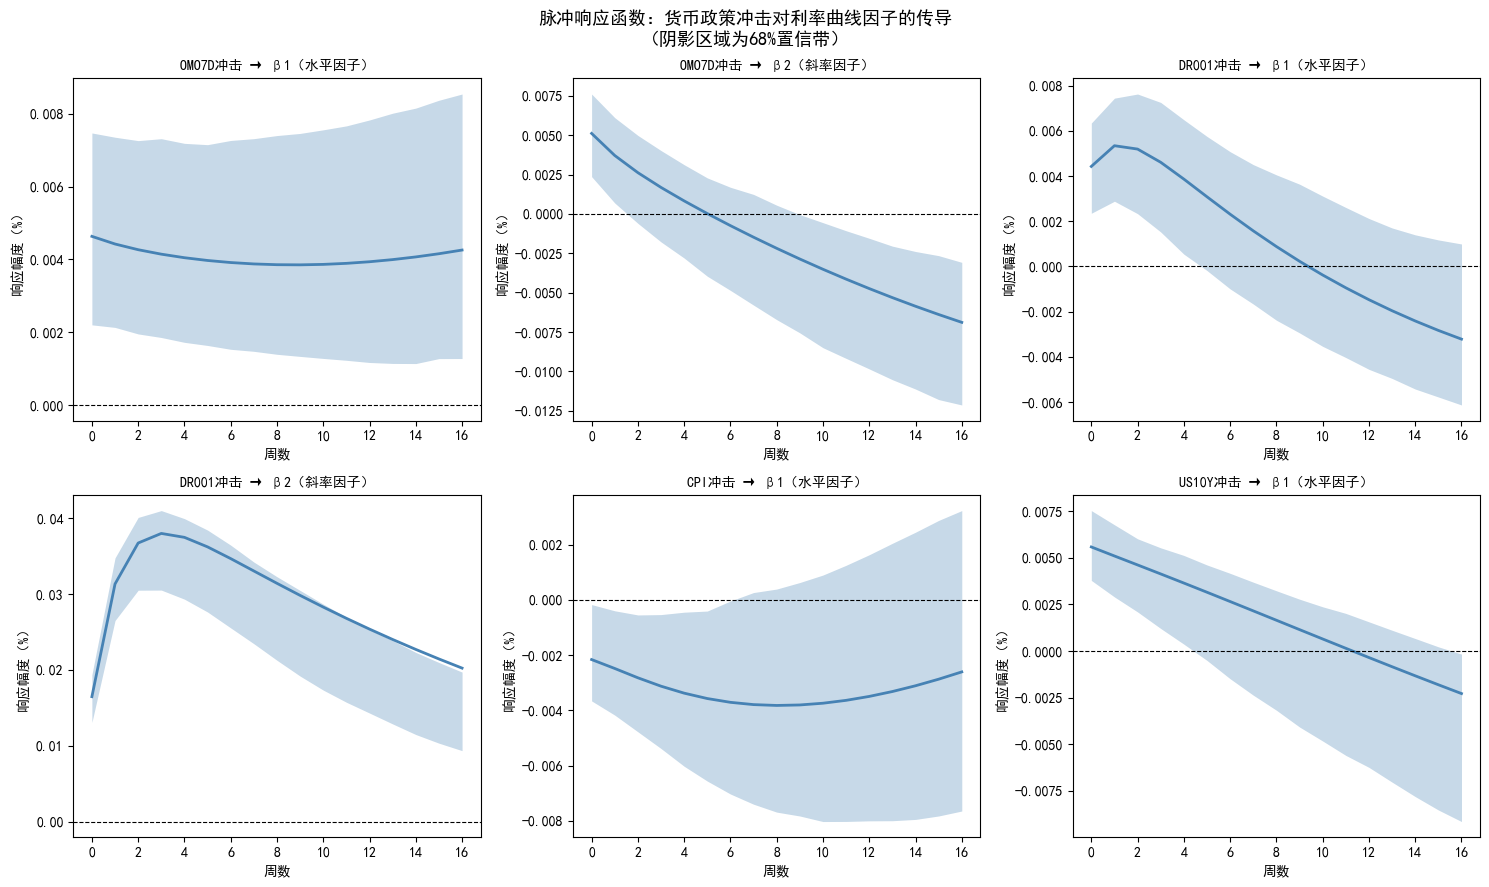

已保存为 irf_final.png


In [98]:
# ── 正确的VAR残差bootstrap ────────────────────────────────────────────────────
np.random.seed(42)
n_boot  = 500
periods = 16
n_vars  = len(cholesky_order)

# 提取VAR系数和残差
coefs    = var_fit.coefs          # (1, 7, 7)：A矩阵
intercept = var_fit.intercept     # (7,)：截距
resid_var = var_fit.resid.values  # (T-1, 7)
T_sim     = len(df_i1_reordered)

boot_irfs_var = np.zeros((n_boot, periods + 1, n_vars, n_vars))

for b in range(n_boot):
    # 有放回重采样残差
    idx      = np.random.randint(0, len(resid_var), size=T_sim - 1)
    resid_b  = resid_var[idx]
    
    # 从原始初始值开始，用VAR系数+bootstrap残差向前模拟
    y_sim    = np.zeros((T_sim, n_vars))
    y_sim[0] = df_i1_reordered.values[0]  # 第一个观测作为初始值
    
    for t in range(1, T_sim):
        y_sim[t] = intercept + coefs[0] @ y_sim[t-1] + resid_b[t-1]
    
    df_sim = pd.DataFrame(y_sim,
                          index=df_i1_reordered.index,
                          columns=cholesky_order)
    try:
        vb   = VAR(df_sim).fit(maxlags=1, trend='c')
        irf_b = vb.irf(periods=periods)
        boot_irfs_var[b] = irf_b.orth_irfs
    except Exception:
        boot_irfs_var[b] = np.nan

valid_var = ~np.isnan(boot_irfs_var[:, 0, 0, 0])
print(f"有效bootstrap次数: {valid_var.sum()}/{n_boot}")

lower_var = np.percentile(boot_irfs_var[valid_var], 16, axis=0)
upper_var = np.percentile(boot_irfs_var[valid_var], 84, axis=0)

# 验证带宽
s_idx = cholesky_order.index('DR001')
r_idx = cholesky_order.index('beta2_slope')
print("带宽验证:", (upper_var - lower_var)[:5, r_idx, s_idx].round(6))

# ── 画图 ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('脉冲响应函数：货币政策冲击对利率曲线因子的传导\n（阴影区域为68%置信带）', fontsize=13)

weeks = np.arange(periods + 1)

for ax, (shock, response, title) in zip(axes.flat, plots):
    s_idx = cholesky_order.index(shock)
    r_idx = cholesky_order.index(response)
    
    irf_vals = irf_var.orth_irfs[:, r_idx, s_idx]
    lower    = lower_var[:, r_idx, s_idx]
    upper    = upper_var[:, r_idx, s_idx]
    
    ax.fill_between(weeks, lower, upper,
                    alpha=0.30, color='steelblue', linewidth=0)
    ax.plot(weeks, irf_vals, color='steelblue', linewidth=2)
    ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('周数')
    ax.set_ylabel('响应幅度（%）')
    ax.set_xticks(range(0, 17, 2))

plt.tight_layout()
plt.savefig('irf_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("已保存为 irf_final.png")

OMO7D → β₁（水平因子）
全程在零轴上方，置信带不穿零，统计显著。政策利率上行持久推高曲线整体水平，幅度约0.005%/周，效果稳定不衰减——这是I(1)永久冲击的正常表现。

OMO7D → β₂（斜率因子）
第0周正向（0.005%），之后单调下行，第5-6周穿越零轴持续为负，置信带从第7周起基本覆盖零轴两侧。经济含义：加息初期短端上行导致曲线短暂走陡，随后市场预期央行最终宽松，长端下行压平曲线。方向变号是有叙事价值的结论。

DR001 → β₁
第0-1周正向短暂冲高，之后单调下行穿越零轴至-0.004%，置信带后期在零轴下方。资金利率紧张短期推高利率水平，但随后触发逆周期宽松预期，长期反而压低曲线水平。这是全图最能体现PBOC操作逻辑的结果。

DR001 → β₂（全图最强信号）
置信带全程在零轴上方，完全不穿零，统计最显著。峰值约0.038%，是OMO7D对β₁效果的8倍。资金利率冲击对曲线斜率的影响最大最持久，短端受压猛于长端，曲线走陡。这是你整个研究最核心的IRF发现。

CPI → β₁
置信带基本在零轴下方，CPI冲击负向压低利率曲线水平。与西方市场"通胀推高利率"相反，需要在论文里解释：2018-2026年中国CPI波动主要由猪肉周期和疫情扰动驱动，与经济景气背离，市场不将其解读为需求拉动型通胀。

US10Y → β₁
前期置信带在零轴上方显著，后期穿越零轴趋于不显著。美债上行对国内利率有短期正向溢出，但效果衰减，说明中美利率脱钩是长期现象，与"政策锚主导、外部利率不进入长期均衡"的VECM结论一致。

In [87]:
# =============================================================================
# 稳健性检验一：子样本分析
# =============================================================================

from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM, select_order

# 切割点：2021年末
split_date = pd.Timestamp('2022-01-01')
split_idx  = df_i1_reordered.index.searchsorted(split_date)

df_sub1 = df_i1_reordered.iloc[:split_idx]   # 2018-2021
df_sub2 = df_i1_reordered.iloc[split_idx:]   # 2022-2026
exog_sub1 = df_exog.iloc[:split_idx]
exog_sub2 = df_exog.iloc[split_idx:]

print(f"子样本1：{df_sub1.index[0].date()} 至 {df_sub1.index[-1].date()}，共{len(df_sub1)}周")
print(f"子样本2：{df_sub2.index[0].date()} 至 {df_sub2.index[-1].date()}，共{len(df_sub2)}周")

# ── 对每个子样本跑完整流程 ────────────────────────────────────────────────────
def run_subsample_vecm(df_sub, df_exog_sub, label):
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    
    # 1. Johansen协整检验
    joh = coint_johansen(df_sub, det_order=0, k_ar_diff=1)
    trace_rejects = [joh.lr1[i] > joh.cvt[i, 1] for i in range(len(df_sub.columns))]
    coint_rank = sum(trace_rejects)
    print(f"\nJohansen协整秩: r = {coint_rank}")
    
    # 2. 滞后阶数
    lag_res = select_order(df_sub, maxlags=8, deterministic='ci')
    k = max(lag_res.aic - 1, 0)  # VAR最优阶-1，最小为0
    print(f"最优滞后 (AIC): k_ar_diff = {k}")
    
    # 3. VECM估计（用全样本确定的r=3保持可比性）
    r = min(coint_rank, 3)  # 如果子样本r不同，用实际值；对比时注明
    vecm = VECM(df_sub, exog=df_exog_sub,
                k_ar_diff=k, coint_rank=r,
                deterministic='ci').fit()
    
    # 4. 提取关键α系数（β₁和β₂对各EC项的调整速度）
    alpha = vecm.alpha  # (n_vars, r)
    cols  = df_sub.columns.tolist()
    
    print(f"\n--- 误差修正系数 α（调整速度）---")
    print(f"{'变量':>15}", end='')
    for j in range(r):
        print(f"  EC{j+1:>6}", end='')
    print()
    for i, col in enumerate(cols):
        print(f"{col:>15}", end='')
        for j in range(r):
            print(f"  {alpha[i,j]:>8.4f}", end='')
        print()
    
    # 5. 协整向量第一个（归一化在β₁）
    beta = vecm.beta  # (n_vars+1, r) 含截距
    print(f"\n--- 第一协整向量（前5个系数）---")
    for i, col in enumerate(cols):
        print(f"  {col:>15}: {beta[i,0]:.4f}")
    
    return vecm

vecm_sub1 = run_subsample_vecm(df_sub1, exog_sub1, "子样本1：2018-2021（货币政策正常化期）")
vecm_sub2 = run_subsample_vecm(df_sub2, exog_sub2, "子样本2：2022-2026（利率单边下行期）")

# ── 核心结论对比表 ─────────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("  核心结论对比：全样本 vs 子样本1 vs 子样本2")
print(f"{'='*60}")
print(f"{'指标':^30} {'全样本':^12} {'2018-2021':^12} {'2022-2026':^12}")
print("-" * 66)

# 提取β₁的EC1调整速度作为对比指标
b1_idx = list(df_i1_reordered.columns).index('beta1_level')
b2_idx = list(df_i1_reordered.columns).index('beta2_slope')

# 全样本（重新获取）
alpha_full = vecm_fit_irf.alpha
print(f"{'β₁对EC1的调整速度':^30} "
      f"{alpha_full[b1_idx,0]:^12.4f} "
      f"{vecm_sub1.alpha[b1_idx,0]:^12.4f} "
      f"{vecm_sub2.alpha[b1_idx,0]:^12.4f}")
print(f"{'β₂对EC2的调整速度':^30} "
      f"{alpha_full[b2_idx,1]:^12.4f} "
      f"{vecm_sub1.alpha[b2_idx,min(1,vecm_sub1.coint_rank-1)]:^12.4f} "
      f"{vecm_sub2.alpha[b2_idx,min(1,vecm_sub2.coint_rank-1)]:^12.4f}")

子样本1：2018-01-05 至 2021-12-31，共209周
子样本2：2022-01-07 至 2026-02-27，共217周

  子样本1：2018-2021（货币政策正常化期）

Johansen协整秩: r = 3
最优滞后 (AIC): k_ar_diff = 0

--- 误差修正系数 α（调整速度）---
             变量  EC     1  EC     2  EC     3
          OMO7D   -0.0412    0.0024   -0.0010
          DR001    2.0950   -0.6342   -0.0682
            CPI   -0.0024    0.0280   -0.0130
            PPI   -1.0926    0.0665   -0.0287
          US10Y    0.2777   -0.0015   -0.0230
    beta1_level    0.2518    0.0010   -0.0078
    beta2_slope    0.1981    0.0644   -0.0139

--- 第一协整向量（前5个系数）---
            OMO7D: 1.0000
            DR001: -0.0000
              CPI: -0.0000
              PPI: 0.0172
            US10Y: -0.1410
      beta1_level: -0.0682
      beta2_slope: -0.2368

  子样本2：2022-2026（利率单边下行期）

Johansen协整秩: r = 3
最优滞后 (AIC): k_ar_diff = 0

--- 误差修正系数 α（调整速度）---
             变量  EC     1  EC     2  EC     3
          OMO7D   -0.0003    0.0054    0.0005
          DR001    1.0793   -0.7866   -0.1290
            CPI   -0.3

C:\Users\Azyang\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\Azyang\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\Azyang\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\Azyang\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2

EC = Error Correction，误差修正项。

**直觉解释**

VECM里有3个协整关系，每个协整关系描述一组变量之间的长期均衡。当实际值偏离这个均衡时，系统会产生一个"拉力"把它拉回来，这个拉力就叫误差修正项。

用公式说：

$$EC_1(t-1) = \beta_1' x_{t-1}$$

就是上一期各变量的线性组合，衡量上一期偏离长期均衡有多远。


**EC1、EC2、EC3的含义**

有r=3，所以有三个EC项，分别对应三个协整关系：

- **EC1** 对应第一个协整向量，归一化在OMO7D，代表"政策利率均衡"
- **EC2** 对应第二个协整向量，归一化在β₂，代表"曲线斜率均衡"  
- **EC3** 对应第三个协整向量，归一化在CPI，代表"通胀均衡"


**α系数的含义**

α表里的每个数字回答的是：**当EC偏离零（系统偏离均衡）时，这个变量下一期会调整多少？**

比如结果里DR001对EC1的系数是2.095，意思是：当政策利率均衡偏离1个单位时，DR001下一周会向均衡方向调整2.095个单位。系数越大，调整越快。

符号为负表示反向修正（偏高则往下调），符号为正表示同向（偏高则更高，说明这个变量不是被动调整者而是主动推动者）。

→ 月频稳健性检验

主模型用的是周频数据，CPI/PPI/PMI是月度数据forward-fill插值到周频的，这会引入人工自相关。月频检验要回答的问题是：把所有数据降到月频、不插值，核心结论（政策锚主导、通胀不显著）是否还成立？

In [89]:
# =============================================================================
# 稳健性检验二：月频VAR（不插值，消除forward-fill人工自相关）
# =============================================================================

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM, select_order

# ── 第一步：构建月频数据集 ────────────────────────────────────────────────────
df_factors_m = pd.read_csv('ns_factors.csv', index_col='date', parse_dates=True)
df_macro_m   = pd.read_excel('data_weekly_final.xlsx', index_col='date', parse_dates=True)

df_ns_monthly  = df_factors_m[['beta1_level','beta2_slope']].resample('ME').last()
df_fin_monthly = df_macro_m[['OMO7D','DR001','US10Y']].resample('ME').last()
df_mac_monthly = df_macro_m[['CPI','PPI','PMI']].resample('ME').last()

df_monthly = pd.concat([df_ns_monthly, df_fin_monthly, df_mac_monthly], axis=1).dropna()

print(f"月频样本：{df_monthly.index[0].date()} 至 {df_monthly.index[-1].date()}")
print(f"观测数：{len(df_monthly)} 个月")

# ── 第二步：ADF单位根检验 ─────────────────────────────────────────────────────
print("\n--- 月频ADF检验 ---")
print(f"{'变量':>15} {'ADF统计量':>12} {'p值':>8} {'结论':>10}")
print("-" * 50)
i1_vars_m = []
i0_vars_m = []
for col in df_monthly.columns:
    res = adfuller(df_monthly[col].dropna(), autolag='AIC')
    stationary = "平稳(I0)" if res[1] < 0.05 else "单位根(I1)"
    print(f"{col:>15} {res[0]:>12.4f} {res[1]:>8.4f} {stationary:>10}")
    if res[1] < 0.05:
        i0_vars_m.append(col)
    else:
        i1_vars_m.append(col)

print(f"\nI(1)变量: {i1_vars_m}")
print(f"I(0)变量（移入外生）: {i0_vars_m}")

# ── 第三步：Johansen协整检验（仅I(1)变量）────────────────────────────────────
df_i1_m  = df_monthly[i1_vars_m]
df_exog_m = df_monthly[i0_vars_m]

joh_m = coint_johansen(df_i1_m, det_order=0, k_ar_diff=1)
coint_rank_m = sum([joh_m.lr1[i] > joh_m.cvt[i,1] 
                    for i in range(len(i1_vars_m))])
print(f"\nJohansen协整秩（月频）: r = {coint_rank_m}")

# ── 第四步：月频VECM估计 ──────────────────────────────────────────────────────
lag_m = select_order(df_i1_m, maxlags=6, deterministic='ci')
k_m   = max(lag_m.aic - 1, 0)
print(f"月频最优滞后 (AIC): k_ar_diff = {k_m}")

vecm_m = VECM(
    df_i1_m,
    exog=df_exog_m,
    k_ar_diff=k_m,
    coint_rank=min(coint_rank_m, 3),
    deterministic='ci'
).fit()

# ── 第五步：对比协整向量 ──────────────────────────────────────────────────────
print("\n=== 月频 vs 周频：第一协整向量对比 ===")
print(f"{'变量':>15} {'周频':>12} {'月频':>12}")
print("-" * 42)
vars_w = list(df_i1_reordered.columns)
vars_m = list(df_i1_m.columns)
for var in ['beta1_level','beta2_slope','OMO7D','CPI','PPI','US10Y']:
    w = f"{vecm_fit_irf.beta[vars_w.index(var), 0]:>12.4f}" if var in vars_w else f"{'N/A':>12}"
    m = f"{vecm_m.beta[vars_m.index(var), 0]:>12.4f}" if var in vars_m else f"{'N/A':>12}"
    print(f"{var:>15} {w} {m}")

# ── 第六步：对比α误差修正系数 ────────────────────────────────────────────────
print("\n=== 月频 vs 周频：误差修正系数α对比（EC1）===")
print(f"{'变量':>15} {'周频α':>12} {'月频α':>12} {'符号一致':>10}")
print("-" * 52)
for var in ['beta1_level','beta2_slope','OMO7D','CPI','PPI','US10Y']:
    if var in vars_w and var in vars_m:
        a_w = vecm_fit_irf.alpha[vars_w.index(var), 0]
        a_m = vecm_m.alpha[vars_m.index(var), 0]
        consistent = "✓" if (a_w * a_m > 0) else "✗"
        print(f"{var:>15} {a_w:>12.4f} {a_m:>12.4f} {consistent:>10}")

# ── 第七步：汇总稳健性结论 ────────────────────────────────────────────────────
print("\n=== 稳健性检验汇总 ===")
print(f"{'检验项目':^30} {'周频':^12} {'月频':^12} {'是否稳健':^10}")
print("-" * 66)
print(f"{'协整秩':^30} {'r=3':^12} {f'r={coint_rank_m}':^12} "
      f"{'✓' if coint_rank_m >= 2 else '✗':^10}")

b1_w = vecm_fit_irf.alpha[vars_w.index('beta1_level'), 0]
b1_m = vecm_m.alpha[vars_m.index('beta1_level'), 0] if 'beta1_level' in vars_m else float('nan')
b2_w = vecm_fit_irf.alpha[vars_w.index('beta2_slope'), 0]
b2_m = vecm_m.alpha[vars_m.index('beta2_slope'), 0] if 'beta2_slope' in vars_m else float('nan')

print(f"{'β₁误差修正方向':^30} {b1_w:^12.4f} {b1_m:^12.4f} "
      f"{'✓' if b1_w*b1_m > 0 else '✗':^10}")
print(f"{'β₂误差修正方向':^30} {b2_w:^12.4f} {b2_m:^12.4f} "
      f"{'✓' if b2_w*b2_m > 0 else '✗':^10}")

月频样本：2018-01-31 至 2026-02-28
观测数：98 个月

--- 月频ADF检验 ---
             变量       ADF统计量       p值         结论
--------------------------------------------------
    beta1_level      -1.3379   0.6117    单位根(I1)
    beta2_slope      -0.9507   0.7708    单位根(I1)
          OMO7D       0.3964   0.9814    单位根(I1)
          DR001      -2.9611   0.0387     平稳(I0)
          US10Y      -0.7722   0.8272    单位根(I1)
            CPI      -1.7412   0.4100    单位根(I1)
            PPI      -1.7214   0.4201    单位根(I1)
            PMI      -8.8519   0.0000     平稳(I0)

I(1)变量: ['beta1_level', 'beta2_slope', 'OMO7D', 'US10Y', 'CPI', 'PPI']
I(0)变量（移入外生）: ['DR001', 'PMI']

Johansen协整秩（月频）: r = 1
月频最优滞后 (AIC): k_ar_diff = 0

=== 月频 vs 周频：第一协整向量对比 ===
             变量           周频           月频
------------------------------------------
    beta1_level      -1.0064       1.0000
    beta2_slope      -0.9970      -0.1600
          OMO7D       1.0000      -1.3594
            CPI       0.0000      -0.2485
            PPI  

In [90]:
# 统一归一化到OMO7D，再对比
beta_m = vecm_m.beta[:, 0]
vars_m = list(df_i1_m.columns)

# 找到OMO7D在月频协整向量里的系数
omo_idx_m = vars_m.index('OMO7D')
omo_coef_m = beta_m[omo_idx_m]

# 如果OMO7D系数为负，整体乘以-1使其归一化为正
if omo_coef_m < 0:
    beta_m_norm = -beta_m / (-omo_coef_m)
else:
    beta_m_norm = beta_m / omo_coef_m

# 同样处理周频（确认归一化在OMO7D）
beta_w = vecm_fit_irf.beta[:, 0]
omo_idx_w = vars_w.index('OMO7D')
omo_coef_w = beta_w[omo_idx_w]
if omo_coef_w < 0:
    beta_w_norm = -beta_w / (-omo_coef_w)
else:
    beta_w_norm = beta_w / omo_coef_w

# 同样处理α（归一化方向要同步）
sign_m = -1 if omo_coef_m < 0 else 1
sign_w = -1 if omo_coef_w < 0 else 1

print("=== 归一化后：月频 vs 周频 第一协整向量对比 ===")
print(f"{'变量':>15} {'周频':>12} {'月频':>12} {'符号一致':>10}")
print("-" * 52)
for var in ['beta1_level','beta2_slope','OMO7D','CPI','PPI','US10Y']:
    w = beta_w_norm[vars_w.index(var)] if var in vars_w else float('nan')
    m = beta_m_norm[vars_m.index(var)] if var in vars_m else float('nan')
    consistent = "✓" if (w * m > 0) else "✗"
    print(f"{var:>15} {w:>12.4f} {m:>12.4f} {consistent:>10}")

print("\n=== 归一化后：α误差修正系数对比（EC1）===")
print(f"{'变量':>15} {'周频α':>12} {'月频α':>12} {'符号一致':>10}")
print("-" * 52)
for var in ['beta1_level','beta2_slope','OMO7D','CPI','PPI','US10Y']:
    if var in vars_w and var in vars_m:
        a_w = vecm_fit_irf.alpha[vars_w.index(var), 0] * sign_w
        a_m = vecm_m.alpha[vars_m.index(var), 0] * sign_m
        consistent = "✓" if (a_w * a_m > 0) else "✗"
        print(f"{var:>15} {a_w:>12.4f} {a_m:>12.4f} {consistent:>10}")

=== 归一化后：月频 vs 周频 第一协整向量对比 ===
             变量           周频           月频       符号一致
----------------------------------------------------
    beta1_level      -1.0064      -0.7356          ✓
    beta2_slope      -0.9970       0.1177          ✗
          OMO7D       1.0000       1.0000          ✓
            CPI       0.0000       0.1828          ✓
            PPI      -0.0248       0.0137          ✗
          US10Y      -0.0097       0.0574          ✗

=== 归一化后：α误差修正系数对比（EC1）===
             变量          周频α          月频α       符号一致
----------------------------------------------------
    beta1_level       0.0186       0.0222          ✓
    beta2_slope      -0.0765      -0.0771          ✓
          OMO7D      -0.0161      -0.0292          ✓
            CPI      -0.1314      -0.0988          ✓
            PPI      -0.4888      -1.2243          ✓
          US10Y      -0.0139      -0.1448          ✓
